In [1]:
!pip install numpy pandas scikit-learn xgboost scipy

In [2]:
import numpy as np
import random

from sklearn.preprocessing import StandardScaler
from sklearn.utils import resample
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report
from scipy.stats import mode
from xgboost import XGBClassifier

In [3]:
random.seed(42)
np.random.seed(42)

In [4]:
# GE
X_ge_train = np.load("../data/processed/GE_train_encoded.npy")
y_ge_train = np.load("../data/processed/GE_train_labels.npy")

X_ge_test = np.load("../data/processed/GE_test_encoded.npy")
y_ge_test = np.load("../data/processed/GE_test_labels.npy")

# DM
X_dm_train = np.load("../data/processed/DM_train_encoded.npy")
y_dm_train = np.load("../data/processed/DM_train_labels.npy")

X_dm_test = np.load("../data/processed/DM_test_encoded.npy")
y_dm_test = np.load("../data/processed/DM_test_labels.npy")

In [5]:
print(X_ge_train.shape, X_dm_train.shape)
print(X_ge_test.shape, X_dm_test.shape)

(487, 64) (99, 16)
(210, 64) (43, 16)


In [6]:
X_train_combined = []
y_train_combined = []

for i in range(len(X_dm_train)):
    matching_indices = [j for j in range(len(X_ge_train)) if y_ge_train[j] == y_dm_train[i]]
    
    j = random.choice(matching_indices)
    
    combined = np.concatenate((X_ge_train[j], X_dm_train[i]))
    
    X_train_combined.append(combined)
    y_train_combined.append(y_dm_train[i])

X_train_combined = np.array(X_train_combined)
y_train_combined = np.array(y_train_combined)

In [7]:
X_test_combined = []
y_test_combined = []

for i in range(len(X_dm_test)):
    matching_indices = [j for j in range(len(X_ge_test)) if y_ge_test[j] == y_dm_test[i]]
    
    j = random.choice(matching_indices)
    
    combined = np.concatenate((X_ge_test[j], X_dm_test[i]))
    
    X_test_combined.append(combined)
    y_test_combined.append(y_dm_test[i])

X_test_combined = np.array(X_test_combined)
y_test_combined = np.array(y_test_combined)

In [8]:
scaler = StandardScaler()

X_train_combined = scaler.fit_transform(X_train_combined)
X_test_combined = scaler.transform(X_test_combined)

In [9]:
n_bags = 10

bags_X = []
bags_y = []

for i in range(n_bags):
    X_bag, y_bag = resample(
        X_train_combined,
        y_train_combined,
        replace=True,
        n_samples=len(X_train_combined),
        random_state=i
    )
    
    bags_X.append(X_bag)
    bags_y.append(y_bag)

In [10]:
svm_models = []

for i in range(n_bags):
    svm = SVC(kernel='rbf', probability=True)
    svm.fit(bags_X[i], bags_y[i])
    svm_models.append(svm)

In [11]:
svm_probs = []

for model in svm_models:
    prob = model.predict_proba(X_test_combined)
    svm_probs.append(prob)

svm_probs = np.array(svm_probs)

avg_probs = np.mean(svm_probs, axis=0)

final_pred_svm = np.argmax(avg_probs, axis=1)

In [12]:
print("=== SVM (Improved) ===")
print("Accuracy:", accuracy_score(y_test_combined, final_pred_svm))
print(classification_report(y_test_combined, final_pred_svm))

=== SVM (Improved) ===
Accuracy: 0.6744186046511628
              precision    recall  f1-score   support

           0       0.64      0.76      0.70        21
           1       0.72      0.59      0.65        22

    accuracy                           0.67        43
   macro avg       0.68      0.68      0.67        43
weighted avg       0.68      0.67      0.67        43



In [13]:
rf_models = []

for i in range(n_bags):
    rf = RandomForestClassifier(n_estimators=200, max_depth=10, random_state=i)
    rf.fit(bags_X[i], bags_y[i])
    rf_models.append(rf)

In [14]:
rf_probs = []

for model in rf_models:
    prob = model.predict_proba(X_test_combined)
    rf_probs.append(prob)

rf_probs = np.array(rf_probs)

avg_probs_rf = np.mean(rf_probs, axis=0)

final_pred_rf = np.argmax(avg_probs_rf, axis=1)

In [15]:
print("=== RF (Improved) ===")
print("Accuracy:", accuracy_score(y_test_combined, final_pred_rf))
print(classification_report(y_test_combined, final_pred_rf))

=== RF (Improved) ===
Accuracy: 0.7209302325581395
              precision    recall  f1-score   support

           0       0.68      0.81      0.74        21
           1       0.78      0.64      0.70        22

    accuracy                           0.72        43
   macro avg       0.73      0.72      0.72        43
weighted avg       0.73      0.72      0.72        43



In [16]:
xgb_models = []

for i in range(n_bags):
    xgb = XGBClassifier(n_estimators=200, max_depth=4, learning_rate=0.05, eval_metric='logloss')
    xgb.fit(bags_X[i], bags_y[i])
    xgb_models.append(xgb)

In [17]:
xgb_probs = []

for model in xgb_models:
    prob = model.predict_proba(X_test_combined)
    xgb_probs.append(prob)

xgb_probs = np.array(xgb_probs)

avg_probs_xgb = np.mean(xgb_probs, axis=0)

final_pred_xgb = np.argmax(avg_probs_xgb, axis=1)

In [18]:
print("=== XGB (Improved) ===")
print("Accuracy:", accuracy_score(y_test_combined, final_pred_xgb))
print(classification_report(y_test_combined, final_pred_xgb))

=== XGB (Improved) ===
Accuracy: 0.6976744186046512
              precision    recall  f1-score   support

           0       0.65      0.81      0.72        21
           1       0.76      0.59      0.67        22

    accuracy                           0.70        43
   macro avg       0.71      0.70      0.70        43
weighted avg       0.71      0.70      0.69        43



In [19]:
n_runs = 5

In [20]:
all_probs = []

In [21]:
for run in range(n_runs):
    
    # ---------- COMBINE TRAIN ----------
    X_train_combined = []
    y_train_combined = []

    for i in range(len(X_dm_train)):
        matching_indices = [j for j in range(len(X_ge_train)) if y_ge_train[j] == y_dm_train[i]]
        j = random.choice(matching_indices)
        
        combined = np.concatenate((X_ge_train[j], X_dm_train[i]))
        
        X_train_combined.append(combined)
        y_train_combined.append(y_dm_train[i])

    X_train_combined = np.array(X_train_combined)
    y_train_combined = np.array(y_train_combined)

    # ---------- COMBINE TEST ----------
    X_test_combined = []
    y_test_combined = []

    for i in range(len(X_dm_test)):
        matching_indices = [j for j in range(len(X_ge_test)) if y_ge_test[j] == y_dm_test[i]]
        j = random.choice(matching_indices)
        
        combined = np.concatenate((X_ge_test[j], X_dm_test[i]))
        
        X_test_combined.append(combined)
        y_test_combined.append(y_dm_test[i])

    X_test_combined = np.array(X_test_combined)
    y_test_combined = np.array(y_test_combined)

    # ---------- SCALING ----------
    scaler = StandardScaler()
    X_train_combined = scaler.fit_transform(X_train_combined)
    X_test_combined = scaler.transform(X_test_combined)

    # ---------- BAGGING ----------
    bags_X = []
    bags_y = []

    for i in range(10):
        X_bag, y_bag = resample(
            X_train_combined,
            y_train_combined,
            replace=True,
            n_samples=len(X_train_combined),
            random_state=i
        )
        bags_X.append(X_bag)
        bags_y.append(y_bag)

    # ---------- MODEL (use XGBoost here - best) ----------
    models = []

    for i in range(10):
        model = XGBClassifier(n_estimators=200, max_depth=4, learning_rate=0.05, eval_metric='logloss')
        model.fit(bags_X[i], bags_y[i])
        models.append(model)

    # ---------- SOFT VOTING ----------
    probs = []

    for model in models:
        prob = model.predict_proba(X_test_combined)
        probs.append(prob)

    probs = np.array(probs)

    avg_probs = np.mean(probs, axis=0)

    all_probs.append(avg_probs)

In [22]:
all_probs = np.array(all_probs)

final_probs = np.mean(all_probs, axis=0)

final_pred = np.argmax(final_probs, axis=1)

In [23]:
print("=== FINAL MULTI-RUN ENSEMBLE ===")
print("Accuracy:", accuracy_score(y_test_combined, final_pred))
print(classification_report(y_test_combined, final_pred))

=== FINAL MULTI-RUN ENSEMBLE ===
Accuracy: 0.9302325581395349
              precision    recall  f1-score   support

           0       0.91      0.95      0.93        21
           1       0.95      0.91      0.93        22

    accuracy                           0.93        43
   macro avg       0.93      0.93      0.93        43
weighted avg       0.93      0.93      0.93        43



In [24]:
X_test_combined = []
y_test_combined = []

for i in range(len(X_dm_test)):
    matching_indices = [j for j in range(len(X_ge_test)) if y_ge_test[j] == y_dm_test[i]]
    j = random.choice(matching_indices)

    combined = np.concatenate((X_ge_test[j], X_dm_test[i]))
    
    X_test_combined.append(combined)
    y_test_combined.append(y_dm_test[i])

X_test_combined = np.array(X_test_combined)
y_test_combined = np.array(y_test_combined)

In [25]:
n_runs = 5
all_probs_svm = []

for run in range(n_runs):

    # TRAIN COMBINATION
    X_train_combined = []
    y_train_combined = []

    for i in range(len(X_dm_train)):
        matching_indices = [j for j in range(len(X_ge_train)) if y_ge_train[j] == y_dm_train[i]]
        j = random.choice(matching_indices)

        combined = np.concatenate((X_ge_train[j], X_dm_train[i]))
        X_train_combined.append(combined)
        y_train_combined.append(y_dm_train[i])

    X_train_combined = np.array(X_train_combined)
    y_train_combined = np.array(y_train_combined)

    # SCALING
    scaler = StandardScaler()
    X_train_combined = scaler.fit_transform(X_train_combined)
    X_test_scaled = scaler.transform(X_test_combined)

    # BAGGING + MODEL
    probs = []

    for i in range(10):
        X_bag, y_bag = resample(X_train_combined, y_train_combined, replace=True)

        model = SVC(kernel='rbf', probability=True)
        model.fit(X_bag, y_bag)

        prob = model.predict_proba(X_test_scaled)
        probs.append(prob)

    probs = np.array(probs)
    avg_probs = np.mean(probs, axis=0)

    all_probs_svm.append(avg_probs)

# FINAL SVM
final_probs_svm = np.mean(all_probs_svm, axis=0)
final_pred_svm = np.argmax(final_probs_svm, axis=1)

print("=== FINAL SVM ===")
print("Accuracy:", accuracy_score(y_test_combined, final_pred_svm))
print(classification_report(y_test_combined, final_pred_svm))

=== FINAL SVM ===
Accuracy: 0.8604651162790697
              precision    recall  f1-score   support

           0       0.80      0.95      0.87        21
           1       0.94      0.77      0.85        22

    accuracy                           0.86        43
   macro avg       0.87      0.86      0.86        43
weighted avg       0.87      0.86      0.86        43



In [26]:
all_probs_rf = []

for run in range(n_runs):

    X_train_combined = []
    y_train_combined = []

    for i in range(len(X_dm_train)):
        matching_indices = [j for j in range(len(X_ge_train)) if y_ge_train[j] == y_dm_train[i]]
        j = random.choice(matching_indices)

        combined = np.concatenate((X_ge_train[j], X_dm_train[i]))
        X_train_combined.append(combined)
        y_train_combined.append(y_dm_train[i])

    X_train_combined = np.array(X_train_combined)
    y_train_combined = np.array(y_train_combined)

    scaler = StandardScaler()
    X_train_combined = scaler.fit_transform(X_train_combined)
    X_test_scaled = scaler.transform(X_test_combined)

    probs = []

    for i in range(10):
        X_bag, y_bag = resample(X_train_combined, y_train_combined, replace=True)

        model = RandomForestClassifier(n_estimators=200, max_depth=10)
        model.fit(X_bag, y_bag)

        prob = model.predict_proba(X_test_scaled)
        probs.append(prob)

    probs = np.array(probs)
    avg_probs = np.mean(probs, axis=0)

    all_probs_rf.append(avg_probs)

# FINAL RF
final_probs_rf = np.mean(all_probs_rf, axis=0)
final_pred_rf = np.argmax(final_probs_rf, axis=1)

print("=== FINAL RF ===")
print("Accuracy:", accuracy_score(y_test_combined, final_pred_rf))
print(classification_report(y_test_combined, final_pred_rf))

=== FINAL RF ===
Accuracy: 0.813953488372093
              precision    recall  f1-score   support

           0       0.81      0.81      0.81        21
           1       0.82      0.82      0.82        22

    accuracy                           0.81        43
   macro avg       0.81      0.81      0.81        43
weighted avg       0.81      0.81      0.81        43



In [27]:
all_probs_xgb = []

for run in range(n_runs):

    X_train_combined = []
    y_train_combined = []

    for i in range(len(X_dm_train)):
        matching_indices = [j for j in range(len(X_ge_train)) if y_ge_train[j] == y_dm_train[i]]
        j = random.choice(matching_indices)

        combined = np.concatenate((X_ge_train[j], X_dm_train[i]))
        X_train_combined.append(combined)
        y_train_combined.append(y_dm_train[i])

    X_train_combined = np.array(X_train_combined)
    y_train_combined = np.array(y_train_combined)

    scaler = StandardScaler()
    X_train_combined = scaler.fit_transform(X_train_combined)
    X_test_scaled = scaler.transform(X_test_combined)

    probs = []

    for i in range(10):
        X_bag, y_bag = resample(X_train_combined, y_train_combined, replace=True)

        model = XGBClassifier(n_estimators=200, max_depth=4, learning_rate=0.05, eval_metric='logloss')
        model.fit(X_bag, y_bag)

        prob = model.predict_proba(X_test_scaled)
        probs.append(prob)

    probs = np.array(probs)
    avg_probs = np.mean(probs, axis=0)

    all_probs_xgb.append(avg_probs)

# FINAL XGB
final_probs_xgb = np.mean(all_probs_xgb, axis=0)
final_pred_xgb = np.argmax(final_probs_xgb, axis=1)

print("=== FINAL XGBOOST ===")
print("Accuracy:", accuracy_score(y_test_combined, final_pred_xgb))
print(classification_report(y_test_combined, final_pred_xgb))

=== FINAL XGBOOST ===
Accuracy: 0.8837209302325582
              precision    recall  f1-score   support

           0       0.81      1.00      0.89        21
           1       1.00      0.77      0.87        22

    accuracy                           0.88        43
   macro avg       0.90      0.89      0.88        43
weighted avg       0.91      0.88      0.88        43



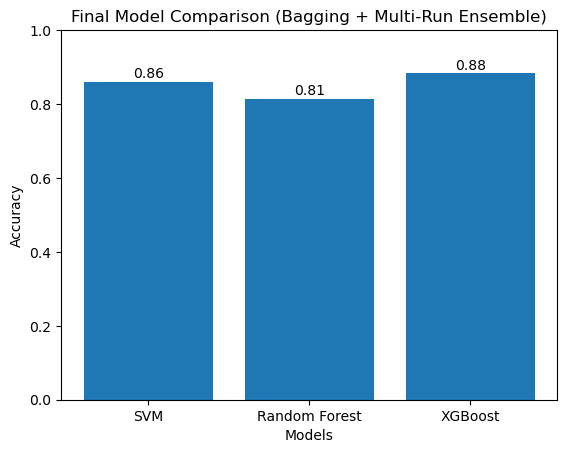

In [32]:
import matplotlib.pyplot as plt

models = ["SVM", "Random Forest", "XGBoost"]
accuracy = [0.8605, 0.8140, 0.8837]

plt.figure()

plt.bar(models, accuracy)

plt.xlabel("Models")
plt.ylabel("Accuracy")
plt.title("Final Model Comparison (Bagging + Multi-Run Ensemble)")

# show values on top
for i, v in enumerate(accuracy):
    plt.text(i, v + 0.01, str(round(v, 2)), ha='center')

plt.ylim(0, 1)

# Save graph
plt.savefig("../results/bagging_results/final_bagging_comparison.png", dpi=300)

plt.show()

In [33]:
import os
os.makedirs("results", exist_ok=True)

In [34]:
from sklearn.metrics import classification_report, accuracy_score

with open("../results/bagging_results/final_bagging_results.txt", "w") as f:
    
    # SVM
    f.write("=== FINAL SVM ===\n")
    f.write(f"Accuracy: {accuracy_score(y_test_combined, final_pred_svm):.4f}\n")
    f.write(classification_report(y_test_combined, final_pred_svm))
    
    # RF
    f.write("\n\n=== FINAL RANDOM FOREST ===\n")
    f.write(f"Accuracy: {accuracy_score(y_test_combined, final_pred_rf):.4f}\n")
    f.write(classification_report(y_test_combined, final_pred_rf))
    
    # XGBoost
    f.write("\n\n=== FINAL XGBOOST ===\n")
    f.write(f"Accuracy: {accuracy_score(y_test_combined, final_pred_xgb):.4f}\n")
    f.write(classification_report(y_test_combined, final_pred_xgb))